# Generate sample reconstructions for a selected sweep model

This notebook shows how to load a trained sweep model and generate sample reconstructions from it. The reconstructions are generated by sampling from the latent space of the model and then decoding those samples back into image space.

In [ ]:
# --- Ensure the correct kernel is available ---
# If you don't see "morphseq (torch-env)" in your kernel list, run this cell
# once with any available Python kernel, then switch to the new kernel.
import subprocess, sys, shutil

ENV_PYTHON = "/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/bin/python"
KERNEL_NAME = "morphseq-torch"

# Check if kernel is already installed for this user
kernels_dir = __import__("pathlib").Path.home() / ".local/share/jupyter/kernels" / KERNEL_NAME
if not kernels_dir.exists():
    subprocess.check_call([
        ENV_PYTHON, "-m", "ipykernel", "install",
        "--user",
        "--name", KERNEL_NAME,
        "--display-name", "morphseq (torch-env)",
    ])
    print(f"Kernel '{KERNEL_NAME}' installed. Please reload the window and select it.")
else:
    print(f"Kernel '{KERNEL_NAME}' already installed. Make sure it is selected above.")

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
from torch.utils.data import DataLoader
from torch.utils.data.sampler import SubsetRandomSampler
import matplotlib.pyplot as plt
import pytorch_lightning as pl

# Ensure repository imports resolve when running notebook from results/...
REPO_ROOT = Path.cwd().resolve()
while REPO_ROOT.name != "morphseq" and REPO_ROOT != REPO_ROOT.parent:
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT))

from src.core.run.run_utils import load_trained_model

/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [9]:
# ===== User selections =====
DATA_ROOT = Path("/net/trapnell/vol1/home/nlammers/projects/data/morphseq/training_data/models")
SWEEP_NAME = "sweep11"
SELECTED_RUN = "sweep11_patch4_20250729_091501"  # set to a full run folder name to force a specific run
RUN_INDEX = -1       # if SELECTED_RUN is None, pick this index from sorted runs
N_SAMPLES = 24
RANDOM_SEED = 42
BATCH_SIZE = N_SAMPLES

# Discover candidate runs
training_outputs = DATA_ROOT / "training_outputs"
candidate_runs = sorted([p for p in training_outputs.glob(f"{SWEEP_NAME}_*") if p.is_dir()])
assert len(candidate_runs) > 0, f"No runs found for pattern: {SWEEP_NAME}_*"

if SELECTED_RUN is not None:
    mdl_path = training_outputs / SELECTED_RUN
    assert mdl_path.exists(), f"Selected run does not exist: {mdl_path}"
else:
    mdl_path = candidate_runs[RUN_INDEX]

sub_runs = sorted([p for p in mdl_path.glob("*") if p.is_dir()])
run_path = sub_runs[0]

print(f"Using run: {run_path}")

Using run: /net/trapnell/vol1/home/nlammers/projects/data/morphseq/training_data/models/training_outputs/sweep11_patch4_20250729_091501/0


In [10]:
# ===== Load model (all legacy fixups handled inside load_trained_model) =====
lit_model, eval_data_config, model_config = load_trained_model(run_path)
print("Model loaded and frozen.")

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/lpips/weights/v0.1/vgg.pth
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/lpips/lpips.py:107: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self.load_state_dic

Loading model from: /net/trapnell/vol1/home/nlammers/micromamba/envs/torch-env/lib/python3.10/site-packages/lpips/weights/v0.1/alex.pth
Model loaded and frozen.


/tmp/8909280.1.trapnell-short.q/ipykernel_1362893/591032255.py:2: UserWarning: load_trained_model: skipped 2 state_dict keys with shape mismatches or renames (e.g. ['model.encoder.backbone.layers.3.blocks.0.attn.relative_position_bias_table', 'model.encoder.backbone.layers.3.blocks.1.attn.relative_position_bias_table'])
  lit_model, eval_data_config, model_config = load_trained_model(run_path)


In [ ]:
# ===== Sample test images and run prediction =====
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

dataset = eval_data_config.create_dataset()
test_indices = np.asarray(eval_data_config.test_indices)
sampled = np.random.permutation(test_indices)[:N_SAMPLES]
sampler = SubsetRandomSampler(sampled)

dl = DataLoader(
    dataset,
    batch_size=BATCH_SIZE,
    num_workers=eval_data_config.num_workers,
    sampler=sampler,
    shuffle=False,
)

trainer = pl.Trainer(accelerator="auto", devices=1, limit_predict_batches=1, logger=False)
lit_model.current_mode = "test"
preds = trainer.predict(lit_model, dataloaders=dl)

assert len(preds) > 0, "No predictions returned."
batch_pred = preds[0]
orig = batch_pred["orig"].detach().cpu()
recon = batch_pred["recon"].detach().cpu()
snip_ids = batch_pred["snip_ids"]
recon_loss = batch_pred["recon_loss"].detach().cpu().numpy()

print(f"Predicted {orig.shape[0]} samples.")

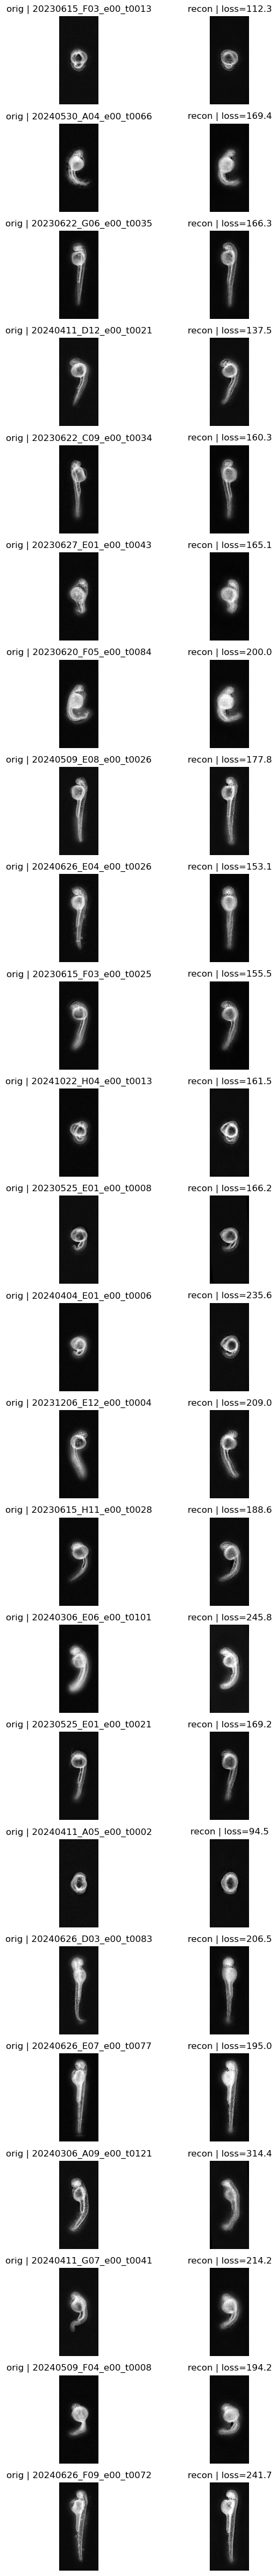

In [12]:
# ===== Display originals and reconstructions in a single figure =====
n_show = orig.shape[0]
fig, axes = plt.subplots(n_show, 2, figsize=(8, max(2*n_show, 6)), squeeze=False)

for i in range(n_show):
    x = orig[i].squeeze().numpy()
    y = recon[i].squeeze().numpy()
    name = Path(snip_ids[i]).stem

    axes[i, 0].imshow(x, cmap="gray")
    axes[i, 0].set_title(f"orig | {name}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(y, cmap="gray")
    axes[i, 1].set_title(f"recon | loss={recon_loss[i]:.1f}")
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()